In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('..\\data\\datos_ventas_icsi.csv')
df

,folio,caja,usuario,dia,fecha,dia_semana,cantidad,producto,importe,valor,utilidad
0,1,Caja 1,admin,0,2024-02-21,Wednesday,1.00,Ariel Oxianillos De 500gm,28.0,25.93,2.07
1,1,Caja 1,admin,0,2024-02-21,Wednesday,1.00,Axion 720gr,29.0,23.97,5.03
2,2,Caja 1,admin,0,2024-02-21,Wednesday,1.00,Whiskas 1kg,53.0,43.79,9.21
3,3,Caja 1,admin,0,2024-02-21,Wednesday,1.00,Yomi Lala Fresa 190ml,11.0,6.50,4.50
4,4,Caja 1,admin,0,2024-02-21,Wednesday,1.00,Trikitrakes 85g,18.0,14.28,3.72
...,...,...,...,...,...,...,...,...,...,...,...
108481,72844,Caja 1,SUSANA,203,2025-07-23,Wednesday,1.00,Sardina Calmex 425g,42.0,1.46,40.54
108482,72844,Caja 1,SUSANA,203,2025-07-23,Wednesday,0.14,Queso Fresco,15.0,11.89,3.11
108483,72845,Caja 1,SUSANA,203,2025-07-23,Wednesday,1.00,Lala deslactosada 1lit,27.0,22.69,4.31
108484,72846,Caja 1,SUSANA,203,2025-07-23,Wednesday,2.00,HUEVO CRIO CONO 30PZ,172.0,161.46,10.54


## Tickets

¿Qué producto es el más vendido?

In [87]:
cantidad_productos = df.groupby('producto')[['cantidad']].sum()
cantidad_productos.sort_values('cantidad', ascending=False)

,cantidad
producto,
MASTER XTREME MAYOREO RECARGA,805958.00
MASTERXTREME MAYOREO RECARGA,703226.50
MASTER TMAC MAYOREO RECARGA,314309.00
RECARGAS XTREME (MULTICEL-MINISUPER),297311.62
MASTER SERVICIOS XTREME,182769.00
...,...
Harina Mayran Agranel 1K,0.50
Salchicha Tipo Hot Dog Agranel,0.50
Chileancho x kg venta agranel,0.37


¿Cuánto es el ticket promedio?

In [174]:
tickets = df.groupby('folio')[['importe']].sum()
tickets.median()

importe    33.0
dtype: float64

Muestra una distribución

In [152]:
df.loc[df['folio'] == 34119]

,folio,caja,usuario,dia,fecha,dia_semana,cantidad,producto,importe,valor,utilidad
51371,34119,Caja 1,JENNY,225,2024-10-03,Thursday,1.0,Clorets Menta 2.8gr 2Pastillas,1.5,0.64,0.86


In [162]:
tickets[(tickets['importe'] > 1) & (tickets['importe'] < 250)].sort_values('importe')

,importe
folio,
6311,1.08
60794,1.50
59416,1.50
59037,1.50
10367,1.50
...,...
9839,248.00
35275,248.00
56270,249.00


In [168]:
edges = [i for i in np.arange(-0.5, 251, 2)]
        # [i for i in np.arange(99.5, 501, 50)] +\
        # [i for i in np.arange(499.5, 2001, 500)]

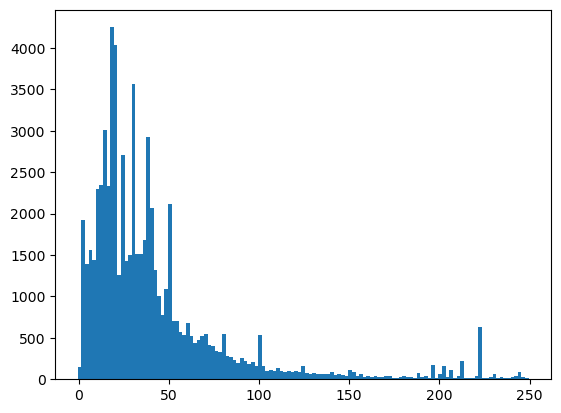

In [170]:
plt.hist(tickets, bins=edges)
plt.show()

## ¿Qué caja vende más?